# Travaux pratiques : Generative Adversarial Networks GAN


Iimporter quelques bibliothèques et sous-modules utiles de PyTorch.

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np

Soit un jeu de données simple : des points répartis le long du cercle unité. Une façon d’obtenir ces points est
d’échantilloner uniformément selon une loi normale et de diviser chaque vecteur par sa norme pour le rendre unitaire :

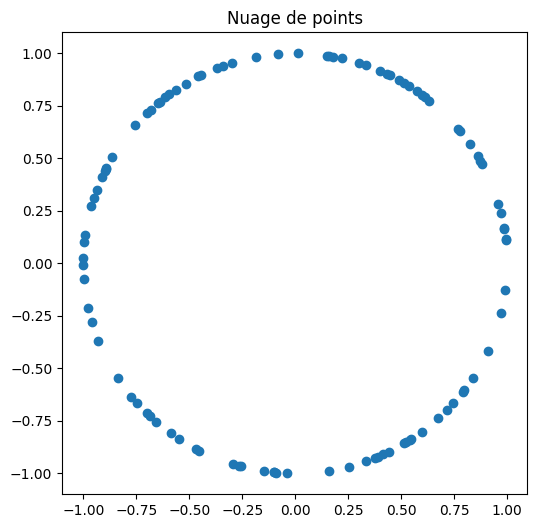

In [19]:
X = np.random.randn(100, 2)
X /= np.linalg.norm(X, axis=1)[:, None].repeat(2, axis=1)


fig = plt.figure(figsize=(6, 6))
plt.scatter(X[:,0], X[:,1])
plt.title("Nuage de points") and plt.show()

On définit ici les paramètres du problème (dimension $ n $ des données d’entrée, ici $ n=2 $, et dimension de l’espace latent).

In [20]:
data_dim = X.shape[-1]
hidden_dim = 10

### Question

Écrire en utilisant l’interface `nn.Sequential` de PyTorch:

- un générateur G entièrement connecté à 3 couches entièrement   connectées qui projette un vecteur $ z $ de l’espace latent de   dimension `hidden_dim` vers un échantillon de dimension  `data_dim` (dimension des données d’entrée),
- un discriminateur D entièrement connecté qui, à partir d’un vecteur   de données (réel ou faux) produit en sortie un valeur entre 0 et 1
  (obtenue en passant le score dans une sigmoïde).  

Pour créer le jeu d’apprentissage, `torch` dispose d’une fonction bien pratique qui permet de transformer automatiquement une matrice d’observation en `Dataset`. Nous pouvons créer le `DataLoader`  :

In [21]:
from torch.utils import data

dataset = data.TensorDataset(torch.Tensor(X))
dataloader = data.DataLoader(dataset, batch_size=100)

(modifiez le paramètre `batch_size` si jamais vous ne disposez pas de suffisamment de mémoire ou si les calculs sont trop lents)

L’apprentissage des poids des réseaux $ \mathcal{D} $ et $ \mathcal{G} $ se fait par des mises à jour séparées. Nous aurons donc besoin de deux optimiseurs différents, un qui porte sur les paramètres du générateur et l’autre qui portent sur les paramètres du discriminateur :

In [22]:
# Générateur : prend un vecteur bruit z (dimension hidden_dim) et produit un point (dimension data_dim)
generator = nn.Sequential(
    nn.Linear(hidden_dim, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(64, data_dim)
)


# Discriminateur : prend un point (dimension data_dim) et produit une probabilité "réel" entre 0 et 1
discriminator = nn.Sequential(
    nn.Linear(data_dim, 64),
    nn.LeakyReLU(0.2),
    nn.Linear(64, 64),
    nn.LeakyReLU(0.2),
    nn.Linear(64, 1),
    nn.Sigmoid()
)

In [23]:
G_optimizer = torch.optim.Adam(generator.parameters(), lr=1e-3, betas=(0.5, 0.999))
D_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-3, betas=(0.5, 0.999))

In [15]:
G_optimizer = torch.optim.Adam(generator.parameters())
D_optimizer = torch.optim.Adam(discriminator.parameters())

### Question

Compléter la boucle d’apprentissage ci-dessous, et notamment le calcul des fonctions de coût pour le générateur et pour le discriminateur.

On rappelle que la méthode `.backward()` permet de rétropropager les gradients d’un tenseur et que `optimizer.step()` permet ensuite de
réaliser un pas de descente de gradient (mise à jour des poids).

**Attention**: il ne faut pas rétropropager le gradient dans $ G $ lorsque vous réalisez une itération sur $ D $. Cela peut se faire à
l’aide de la méthode `.detach()` qui permet de signifier à PyTorch que vous n’aurez pas besoin du gradient pour le tenseur concerné.

In [32]:
from tqdm.notebook import tqdm, trange

loss_fn = nn.BCELoss()  # binary cross-entropy, adaptée car D produit une proba

n_epochs = 1000

for epoch in trange(n_epochs):
    for (real_data,) in tqdm(dataloader, leave=False):
        batch_size = real_data.shape[0]

        # Étape 1 : entraîner le discriminateur
        z = torch.randn(batch_size, hidden_dim)
        fake_data = generator(z).detach() 

        D_real = discriminator(real_data)
        D_fake = discriminator(fake_data)

        # D doit dire "1" pour le vrai, "0" pour le faux
        loss_D = loss_fn(D_real, torch.ones_like(D_real)) + \
                  loss_fn(D_fake, torch.zeros_like(D_fake))

        D_optimizer.zero_grad()
        loss_D.backward()
        D_optimizer.step()

        # Étape 2 : entraîner le générateur
        z = torch.randn(batch_size, hidden_dim)
        fake_data = generator(z)  # pas de detach : on veut le gradient vers G

        D_fake = discriminator(fake_data)

        # G veut tromper D : D doit dire "1" (réel) sur ses fausses données
        loss_G = loss_fn(D_fake, torch.ones_like(D_fake))

        G_optimizer.zero_grad()
        loss_G.backward()
        G_optimizer.step()

    if epoch % 50 == 0:
        print(f"Époque {epoch} — loss_D: {loss_D.item():.3f}, loss_G: {loss_G.item():.3f}")

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Époque 0 — loss_D: 1.030, loss_G: 0.976


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

### Question

Tirez aléatoirement des vecteurs $ z $ de bruit selon une loi normale. Générez les points associés et visualisez côte à côte le nuage de points réel et le nuage de points synthétique.

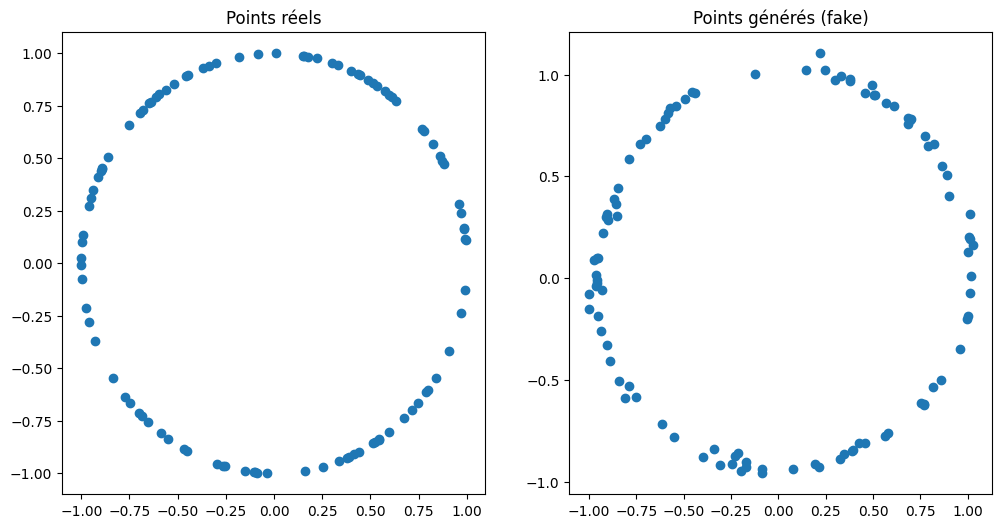

In [33]:
# Tirer des vecteurs de bruit z, un par point réel
z = torch.randn(X.shape[0], hidden_dim)

# Générer les points synthétiques à partir de z
with torch.no_grad():  
    fake_data = generator(z).numpy()

# Affichage côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].scatter(X[:, 0], X[:, 1])
axes[0].set_title("Points réels")

axes[1].scatter(fake_data[:, 0], fake_data[:, 1])
axes[1].set_title("Points générés (fake)")

plt.show()

### Question

Colorez les points générés en fonction de la classe (“real” ou “fake”) prédite par le discriminateur. On mettera le seuil à 0.5.

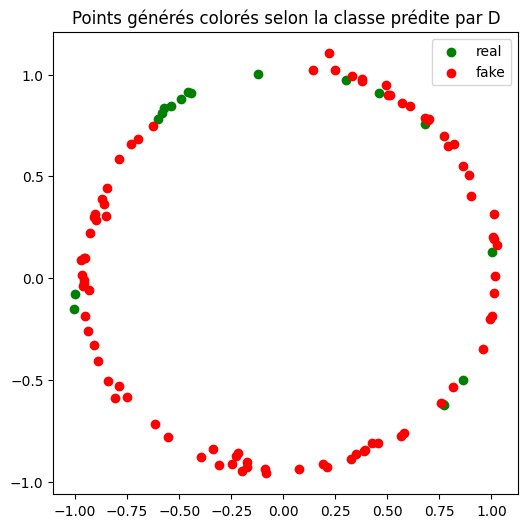

In [34]:
# Passer les points générés dans le discriminateur pour obtenir une proba
with torch.no_grad():
    D_pred = discriminator(torch.Tensor(fake_data)).numpy().flatten()

predicted_class = np.where(D_pred >= 0.5, "real", "fake") # Seuil = 0.5 

plt.figure(figsize=(6, 6))

for label, color in [("real", "green"), ("fake", "red")]:
    mask = predicted_class == label
    plt.scatter(fake_data[mask, 0], fake_data[mask, 1], c=color, label=label)

plt.title("Points générés colorés selon la classe prédite par D")
plt.legend()
plt.show()

### Swiss roll

Le *swiss roll* (gâteau roulé) est un jeu de données tridimensionnel formant un plan replié sur lui-même.

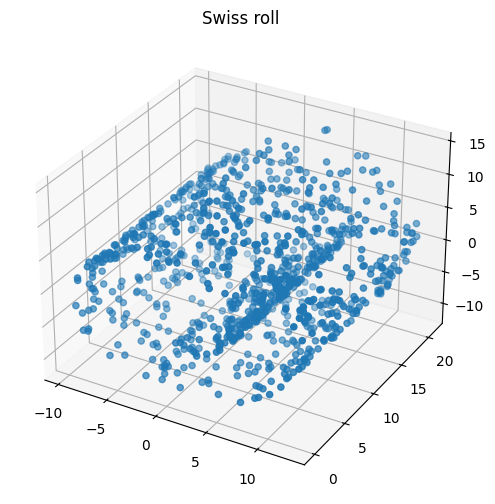

In [54]:
from sklearn.datasets import make_swiss_roll

# Générer le swiss roll (3D)
X_swiss, _ = make_swiss_roll(n_samples=1000, noise=0.1)
X_swiss = X_swiss.astype(np.float32)

# Visualisation en 3D 
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2])
ax.set_title("Swiss roll")
plt.show()

### Question

 Répétez l’expérience ci-dessous. Que constatez-vous lorsque vous diminuez la dimensionalité de l’espace latent ?

In [55]:
data_dim = X_swiss.shape[-1]  # 3 au lieu de 2

dataset_swiss = data.TensorDataset(torch.Tensor(X_swiss))
dataloader_swiss = data.DataLoader(dataset_swiss, batch_size=100)

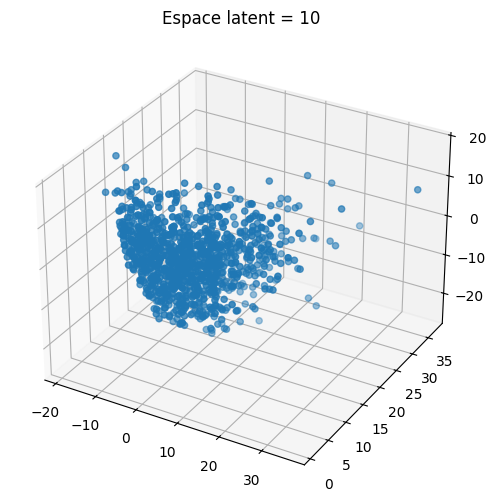

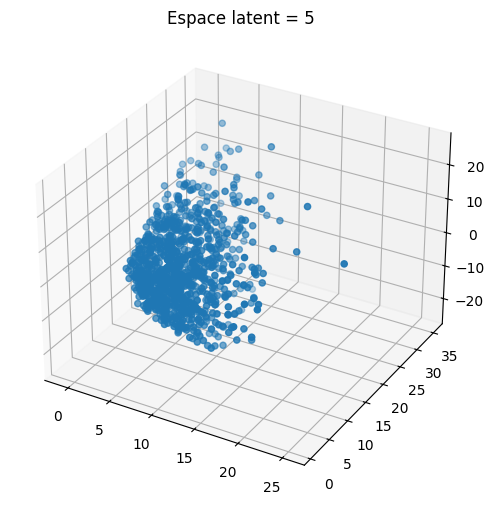

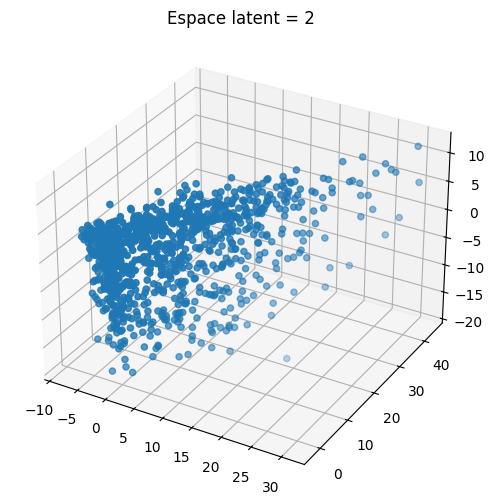

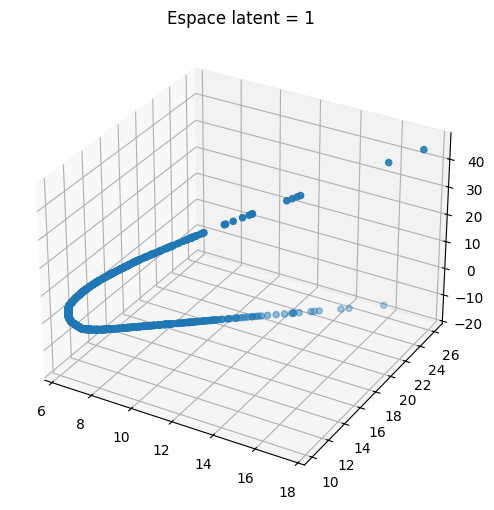

In [56]:
def train_and_plot_swiss(latent_dim, n_epochs=300):
    data_dim = X_swiss.shape[-1]  # 3

    generator = nn.Sequential(
        nn.Linear(latent_dim, 32),
        nn.ReLU(),
        nn.Linear(32, 32),
        nn.ReLU(),
        nn.Linear(32, data_dim)
    )
    discriminator = nn.Sequential(
        nn.Linear(data_dim, 32),
        nn.ReLU(),
        nn.Linear(32, 32),
        nn.ReLU(),
        nn.Linear(32, 1),
        nn.Sigmoid()
    )

    G_optimizer = torch.optim.Adam(generator.parameters(), lr=2e-4)
    D_optimizer = torch.optim.Adam(discriminator.parameters(), lr=2e-4)
    loss_fn = nn.BCELoss()

    # Entraînement 
    for epoch in range(n_epochs):
        for (real_data,) in dataloader_swiss:
            batch_size = real_data.shape[0]

            z = torch.randn(batch_size, latent_dim)
            fake_data = generator(z).detach()
            D_real = discriminator(real_data)
            D_fake = discriminator(fake_data)
            loss_D = loss_fn(D_real, torch.ones_like(D_real)) + \
                      loss_fn(D_fake, torch.zeros_like(D_fake))
            D_optimizer.zero_grad(); loss_D.backward(); D_optimizer.step()

            z = torch.randn(batch_size, latent_dim)
            fake_data = generator(z)
            D_fake = discriminator(fake_data)
            loss_G = loss_fn(D_fake, torch.ones_like(D_fake))
            G_optimizer.zero_grad(); loss_G.backward(); G_optimizer.step()

    # Génération finale et affichage en 3D
    with torch.no_grad():
        z = torch.randn(X_swiss.shape[0], latent_dim)
        fake_data = generator(z).numpy()

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(projection='3d')
    ax.scatter(fake_data[:, 0], fake_data[:, 1], fake_data[:, 2])
    ax.set_title(f"Espace latent = {latent_dim}")
    plt.show()

# Tester plusieurs dimensions
for dim in [10, 5, 2, 1]:
    train_and_plot_swiss(dim)

plus on réduit la dimension de l'espace latent, plus la variété que peut produire le générateur est limitée, elle devient elle-même de dimension réduite.

## Génération de chiffres manuscrits avec MNIST

## Question

Reprendre le code précédent et l’adapter à la dimensionalité de MNIST.
On rappelle qu’une image de MNIST est de dimensions $ 28\times28 $, c’est-à-dire un vecteur de dimension 784 une fois aplati.

Implémenter un GAN **conditionnel** sur MNIST. On utilisera comme vecteur de conditionnement $ y $ la classe du chiffre sous forme de vecteur suivant l’encodage *one-hot*. Visualiser les chiffres obtenus.

In [29]:
! pip install torchvision

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ---------------------- ----------------- 0.8/1.4 MB 2.1 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 1.9 MB/s  0:00:00
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.8/124.1 MB 2.2 MB/s eta 0:00:56
   ---------------------------------------- 1.3/124.1 MB 2.3 MB/s eta 0:00:54
    --------------------------------------- 1.8/124.1 MB 2.3 MB/s eta 0:00:53
    --------------------------------------- 2.4/124.1 MB 2.2 MB/s eta 0:00:56
    --------------------------------------- 2.9/124.1 MB 2.3 MB/s eta 0:00:54
   - -------------------------------------- 3.1/124.1 MB 2.3 MB/s eta 0:00:54
   - ----------------------

  You can safely remove it manually.

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
from torchvision import datasets, transforms

#Charger MNIST et préparer les données
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)) 
])

mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader_mnist = data.DataLoader(mnist, batch_size=128, shuffle=True)

data_dim = 28 * 28  
n_classes = 10
latent_dim = 16

In [51]:
# Le générateur reçoit z ET le one-hot de la classe concaténés
generator = nn.Sequential(
    nn.Linear(latent_dim + n_classes, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, data_dim),
    nn.Sigmoid()
)

# Le discriminateur reçoit l'image ET le one-hot de la classe concaténés
discriminator = nn.Sequential(
    nn.Linear(data_dim + n_classes, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid()
)

G_optimizer = torch.optim.Adam(generator.parameters(), lr=1e-4)
D_optimizer = torch.optim.Adam(discriminator.parameters(), lr=2e-4)
loss_fn = nn.BCELoss()

In [54]:
from tqdm.notebook import tqdm, trange

n_epochs = 50

for epoch in trange(n_epochs):
    for i, (real_imgs, labels) in enumerate(dataloader_mnist):
        batch_size = real_imgs.shape[0]

        # Convertir les labels en one-hot
        y_onehot = F.one_hot(labels, n_classes).float()

        # Entraîner D 
        if i % 3 == 0:
            z = torch.randn(batch_size, latent_dim)
            fake_imgs = generator(torch.cat([z, y_onehot], dim=1)).detach()

            D_real = discriminator(torch.cat([real_imgs, y_onehot], dim=1))
            D_fake = discriminator(torch.cat([fake_imgs, y_onehot], dim=1))

            loss_D = loss_fn(D_real, torch.ones_like(D_real)) + \
                    loss_fn(D_fake, torch.zeros_like(D_fake))

            D_optimizer.zero_grad(); loss_D.backward(); D_optimizer.step()

        # Entraîner G 
        z = torch.randn(batch_size, latent_dim)
        fake_imgs = generator(torch.cat([z, y_onehot], dim=1))
        D_fake = discriminator(torch.cat([fake_imgs, y_onehot], dim=1))

        loss_G = loss_fn(D_fake, torch.ones_like(D_fake))

        G_optimizer.zero_grad(); loss_G.backward(); G_optimizer.step()

    print(f"Époque {epoch} — loss_D: {loss_D.item():.3f}, loss_G: {loss_G.item():.3f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Époque 0 — loss_D: 1.243, loss_G: 0.962
Époque 1 — loss_D: 1.518, loss_G: 0.770
Époque 2 — loss_D: 1.262, loss_G: 0.807
Époque 3 — loss_D: 1.454, loss_G: 0.803
Époque 4 — loss_D: 1.390, loss_G: 0.804
Époque 5 — loss_D: 1.516, loss_G: 0.726
Époque 6 — loss_D: 1.491, loss_G: 0.673
Époque 7 — loss_D: 1.313, loss_G: 0.751
Époque 8 — loss_D: 1.269, loss_G: 0.792
Époque 9 — loss_D: 1.269, loss_G: 0.814
Époque 10 — loss_D: 1.380, loss_G: 0.743
Époque 11 — loss_D: 1.290, loss_G: 0.838
Époque 12 — loss_D: 1.219, loss_G: 0.823
Époque 13 — loss_D: 1.302, loss_G: 0.812
Époque 14 — loss_D: 1.437, loss_G: 0.824
Époque 15 — loss_D: 1.233, loss_G: 0.818
Époque 16 — loss_D: 1.383, loss_G: 0.867
Époque 17 — loss_D: 1.344, loss_G: 0.829
Époque 18 — loss_D: 1.314, loss_G: 0.812
Époque 19 — loss_D: 1.319, loss_G: 0.785
Époque 20 — loss_D: 1.294, loss_G: 0.801
Époque 21 — loss_D: 1.547, loss_G: 0.680
Époque 22 — loss_D: 1.200, loss_G: 0.857
Époque 23 — loss_D: 1.347, loss_G: 0.835
Époque 24 — loss_D: 1.293,

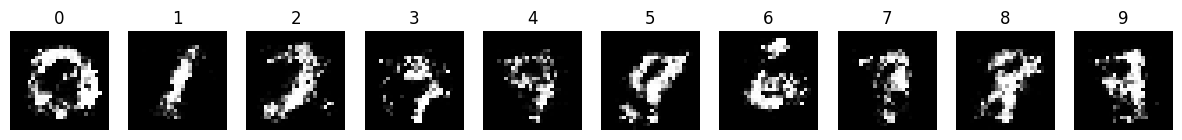

In [55]:
with torch.no_grad():
    z = torch.randn(n_classes, latent_dim)
    y_onehot = F.one_hot(torch.arange(n_classes), n_classes).float()
    generated = generator(torch.cat([z, y_onehot], dim=1))

fig, axes = plt.subplots(1, n_classes, figsize=(15, 2))
for i in range(n_classes):
    axes[i].imshow(generated[i].view(28, 28), cmap='gray')
    axes[i].set_title(str(i))
    axes[i].axis('off')
plt.show()

## Question

 Remplacez $ G $ et $ D $ définis ci-dessus par des modèles convolutifs. On pourra notamment utiliser à bon escient les modules `Upsample` ou
`Conv2DTranspose` pour gérer l’augmentation des dimensions dans le générateur.


In [ ]:
# Charger les données
transform_conv = transforms.Compose([
    transforms.ToTensor()  
])

mnist_conv = datasets.MNIST(root='./data', train=True, download=True, transform=transform_conv)
dataloader_conv = data.DataLoader(mnist_conv, batch_size=128, shuffle=True)

In [57]:
# Générateur convlutif
class GeneratorConv(nn.Module):
    def __init__(self, latent_dim, n_classes):
        super().__init__()
        # Projeter (z + y_onehot) vers une petite carte 7x7 avec 128 canaux
        self.fc = nn.Linear(latent_dim + n_classes, 128 * 7 * 7)

        self.conv = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # 7x7 -> 14x14
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # 14x14 -> 28x28
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()  # pixels entre 0 et 1
        )

    def forward(self, z, y_onehot):
        x = torch.cat([z, y_onehot], dim=1)
        x = self.fc(x)
        x = x.view(-1, 128, 7, 7)  # reshape en petite image
        return self.conv(x)

generator = GeneratorConv(latent_dim, n_classes)

In [58]:
#Discriminateur Convolutif
class DiscriminatorConv(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        # image (1 canal) + n_classes canaux de conditionnement = 1 + 10 canaux en entrée
        self.conv = nn.Sequential(
            nn.Conv2d(1 + n_classes, 64, kernel_size=4, stride=2, padding=1),  # 28x28 -> 14x14
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 14x14 -> 7x7
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, img, y_onehot):
        batch_size = img.shape[0]
        # Transformer y_onehot (batch, n_classes) en carte (batch, n_classes, 28, 28)
        y_map = y_onehot.view(batch_size, n_classes, 1, 1).expand(-1, -1, 28, 28)
        x = torch.cat([img, y_map], dim=1)  # concaténer sur les canaux
        x = self.conv(x)
        x = x.view(batch_size, -1)  # aplatir avant la couche finale
        return self.fc(x)

discriminator = DiscriminatorConv(n_classes)

G_optimizer = torch.optim.Adam(generator.parameters(), lr=1e-4)
D_optimizer = torch.optim.Adam(discriminator.parameters(), lr=2e-4)
loss_fn = nn.BCELoss()

In [59]:
#Boucle d'entraînement
n_epochs = 20

for epoch in trange(n_epochs):
    for i, (real_imgs, labels) in enumerate(dataloader_conv):
        batch_size = real_imgs.shape[0]
        y_onehot = F.one_hot(labels, n_classes).float()

        # Entraîner D (1 fois sur 3)
        if i % 3 == 0:
            z = torch.randn(batch_size, latent_dim)
            fake_imgs = generator(z, y_onehot).detach()

            D_real = discriminator(real_imgs, y_onehot)
            D_fake = discriminator(fake_imgs, y_onehot)

            loss_D = loss_fn(D_real, torch.ones_like(D_real)) + \
                      loss_fn(D_fake, torch.zeros_like(D_fake))

            D_optimizer.zero_grad(); loss_D.backward(); D_optimizer.step()

        # Entraîner G
        z = torch.randn(batch_size, latent_dim)
        fake_imgs = generator(z, y_onehot)
        D_fake = discriminator(fake_imgs, y_onehot)

        loss_G = loss_fn(D_fake, torch.ones_like(D_fake))

        G_optimizer.zero_grad(); loss_G.backward(); G_optimizer.step()

    print(f"Époque {epoch} — loss_D: {loss_D.item():.3f}, loss_G: {loss_G.item():.3f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Époque 0 — loss_D: 0.377, loss_G: 2.505
Époque 1 — loss_D: 0.521, loss_G: 2.114
Époque 2 — loss_D: 0.611, loss_G: 1.783
Époque 3 — loss_D: 1.034, loss_G: 0.745
Époque 4 — loss_D: 1.137, loss_G: 1.227
Époque 5 — loss_D: 1.048, loss_G: 1.341
Époque 6 — loss_D: 1.016, loss_G: 0.983
Époque 7 — loss_D: 0.908, loss_G: 1.275
Époque 8 — loss_D: 0.867, loss_G: 1.583
Époque 9 — loss_D: 1.117, loss_G: 1.165
Époque 10 — loss_D: 1.001, loss_G: 1.541
Époque 11 — loss_D: 1.059, loss_G: 1.194
Époque 12 — loss_D: 1.209, loss_G: 1.017
Époque 13 — loss_D: 1.370, loss_G: 0.714
Époque 14 — loss_D: 1.070, loss_G: 1.202
Époque 15 — loss_D: 1.030, loss_G: 1.129
Époque 16 — loss_D: 1.199, loss_G: 0.903
Époque 17 — loss_D: 1.132, loss_G: 0.948
Époque 18 — loss_D: 1.287, loss_G: 0.817
Époque 19 — loss_D: 1.378, loss_G: 0.747


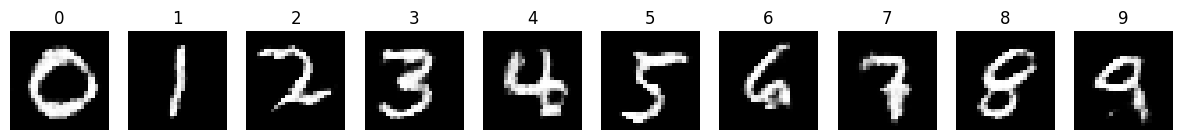

In [60]:
#Visualisation
with torch.no_grad():
    z = torch.randn(n_classes, latent_dim)
    y_onehot = F.one_hot(torch.arange(n_classes), n_classes).float()
    generated = generator(z, y_onehot)

fig, axes = plt.subplots(1, n_classes, figsize=(15, 2))
for i in range(n_classes):
    axes[i].imshow(generated[i, 0].numpy(), cmap='gray')
    axes[i].set_title(str(i))
    axes[i].axis('off')
plt.show()

les couches convolutives exploitent la structure spatiale locale des images (contours, courbes, proximité des pixels) bien mieux que les couches fully-connected, qui traitent chaque pixel indépendamment sans notion de voisinage.